# `abspc` — Python Quick Start for Quality Improvement

This is a **5-minute quick start** for QI teams who want to build an NHS
Making Data Count (MDC) SPC chart from a CSV / Excel extract or a hand-typed
list of values.

**You will:**
1. Install `abspc`
2. Load (or fabricate) a small data set
3. Pick the right chart type
4. Render a publication-ready chart with target line, MDC icons, and a logo

> All values in this notebook are **fake** for illustration. Replace them with
> your own measure when you are ready.


## 1. Install

`abspc` is on PyPI. Run this once per environment.

```bash
pip install abspc
```


In [1]:
# Uncomment to install from PyPI inside a notebook
# %pip install abspc

# (Optional) make the package importable when running from a clone of the repo
import sys, pathlib
for _candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (_candidate / "abspc" / "__init__.py").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

import abspc
print("abspc", abspc.__version__)

abspc 1.0.0


## 2. Load your data

Three common patterns:

- **CSV / Excel** — `pd.read_csv(...)` / `pd.read_excel(...)`
- **A hand-typed list** — useful for board-paper one-offs
- **A SQL query** — `pd.read_sql(query, conn)`

Below we build a fake monthly time series. Replace this cell with your own
loading code.


In [2]:
import numpy as np
import pandas as pd

dates  = pd.date_range("2024-01-01", periods=18, freq="MS")
rng    = np.random.default_rng(7)
values = np.clip(rng.normal(78, 4, len(dates)), 60, 95)

df = pd.DataFrame({"value": values}, index=dates)
df.head()

,value
2024-01-01,78.004921
2024-02-01,79.194982
2024-03-01,76.903449
2024-04-01,74.437633
2024-05-01,76.181317


## 3. Pick a chart type

| Your data look like… | Use |
|---|---|
| Continuous values, one per period (LoS, % seen) | `XmR` |
| A proportion with a varying denominator (% of admissions, % DNA) | `p` |
| A count of events with a *fixed* exposure (falls per ward-month) | `c` |
| A count of events with a *variable* exposure (incidents per 1,000 bed-days) | `u` |
| Too few points (< ~12) or process not yet stable | `run` |

If unsure, start with **XmR** — it works for almost any continuous measure.


## 4. Render the chart

The single function `plot_spc_chart` covers every chart type. Set
`improvement_direction` to `"high"` or `"low"` so the package can colour
points correctly and decide assurance against your target.


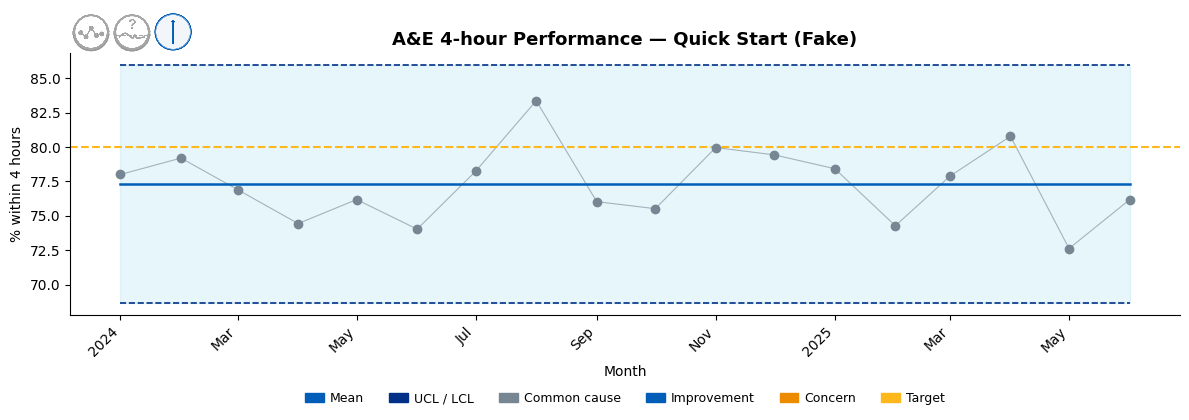

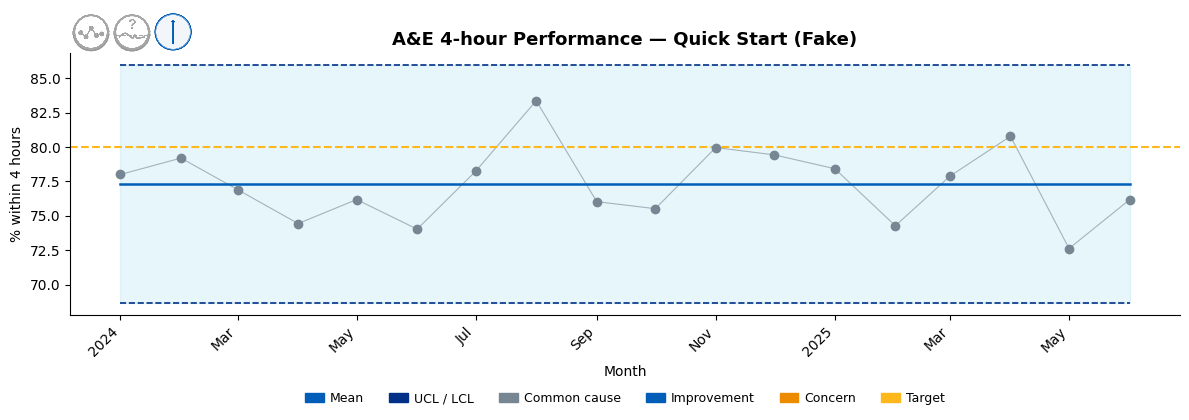

In [3]:
from abspc import plot_spc_chart

fig, ax = plot_spc_chart(
    df,
    chart_type="XmR",
    title="A&E 4-hour Performance — Quick Start (Fake)",
    xlabel="Month",
    ylabel="% within 4 hours",
    improvement_direction="high",
    target=80,
    show_target=True,
    show_icons=True,    # MDC variation + assurance icons
    shade_band=True,    # tolerance band between UCL and LCL
)

fig.savefig("my_first_spc_chart.png", dpi=150, bbox_inches="tight")
fig

## 5. Get the underlying numbers

You don't have to plot to use the analytics. Every plotting function has a
twin that just returns a DataFrame, so you can drop the results into Excel,
Power BI, or a board paper.


In [4]:
from abspc import (
    calculate_control_limits,
    detect_special_causes,
    show_summary,
)

result = detect_special_causes(calculate_control_limits(df, chart_type="XmR"))
result[["value", "mean", "ucl", "lcl", "special_cause"]].tail()

,value,mean,ucl,lcl,special_cause
2025-02-01,74.278128,77.302778,85.960361,68.645196,False
2025-03-01,77.882993,77.302778,85.960361,68.645196,False
2025-04-01,80.781213,77.302778,85.960361,68.645196,False
2025-05-01,72.623142,77.302778,85.960361,68.645196,False
2025-06-01,76.169537,77.302778,85.960361,68.645196,False


In [5]:
summary = show_summary(
    df, chart_type="XmR", improvement_direction="high", target=80,
)
print("Variation:", summary["variation"])
print("Assurance:", summary["assurance"])
print("Rules triggered:", summary["rules_triggered"])

Variation: Common-cause variation
Assurance: Hit or miss — may or may not meet target
Rules triggered: {}


## 6. From a SQL query (optional)

A common QI pattern is to keep the *query* in source control and let the
notebook handle visualisation. Skeleton:

```python
import sqlalchemy as sa, pandas as pd
from abspc import plot_spc_chart

engine = sa.create_engine("<your connection string>")

QUERY = '''
SELECT month_start                              AS period,
       seen_within_4h * 1.0 / total_attendances AS value
FROM   ae_monthly
WHERE  site = :site
ORDER  BY month_start
'''

df = pd.read_sql(sa.text(QUERY), engine, params={"site": "ABUHB"},
                 parse_dates=["period"], index_col="period")

fig, _ = plot_spc_chart(df, chart_type="XmR",
                        improvement_direction="high", target=0.80,
                        show_icons=True)
```


## 7. Where next?

- [`docs/QI_GUIDE.md`](QI_GUIDE.md) — how to use these charts in your QI work.
- [`abspc/README.md`](../abspc/README.md) — full API reference (`plot_spc_chart`,
  `plot_run_chart`, `plot_mdc_summary_table`, `show_summary`,
  `rebase_control_limits`, …).
- [`docs/screenshots.ipynb`](screenshots.ipynb) — every gallery image
  regenerated end-to-end on the latest version of `abspc`.
